# Notebook 1: Exploring skin tone imbalance in Fitzpatrick17k

Goal of this notebook: see how skin tones and diseases are distributed in the dataset before training any model.

In [2]:
# Install the libraries used in this project
!pip install -q torch torchvision torchaudio albumentations Pillow opencv-python-headless scikit-learn matplotlib seaborn pandas

In [3]:
import torch
import torchvision
from PIL import Image
import cv2
import albumentations as A
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Scikit-Learn version:", sklearn.__version__)
print("All libraries successfully imported!")

PyTorch version: 2.11.0+cu130
CUDA available: True
Scikit-Learn version: 1.6.1
All libraries successfully imported!


Loading the Fitzpatrick17k metadata directly from the official GitHub repository

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(16577, 9)


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


The dataset contains 16,577 images and 9 columns. Each image has a unique identifier (md5hash) and two Fitzpatrick skin type annotations, from Scale AI and Centaur Labs. The two annotators sometimes disagree (e.g. row 2: type 2 vs type 3), which shows that estimating skin tone from a picture is partly subjective.

In [5]:
print(df.columns.tolist())
print(df["fitzpatrick_scale"].value_counts().sort_index())
print(df["three_partition_label"].value_counts())

['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']
fitzpatrick_scale
-1     565
 1    2947
 2    4808
 3    3308
 4    2781
 5    1533
 6     635
Name: count, dtype: int64
three_partition_label
non-neoplastic    12080
malignant          2263
benign             2234
Name: count, dtype: int64


Skin tones are strongly imbalanced: light skin (types 1-2) represents 48% of the images with a known skin type, against only 14% for dark skin (types 5-6), a 3.6 to 1 ratio. Type 6 alone accounts for about 4% of the images. 565 images have an unknown skin type (-1) and will be removed. Diseases are also imbalanced: 73% non-neoplastic, 14% malignant and 13% benign. A model trained on this data may therefore perform worse on dark skin.


So the next step is to delete the unknown skin colors. Then group the colors in 3 groups, light, medium and dark.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unknown skin colors
df = df[df["fitzpatrick_scale"] != -1].copy()

# Group skin colors in 3 types
groupes = {1: "Light (1-2)", 2: "Light (1-2)", 3: "Medium (3-4)",
           4: "Medium (3-4)", 5: "Dark (5-6)", 6: "Dark (5-6)"}
df["skin_group"] = df["fitzpatrick_scale"].map(groupes)




Then we make graphs to the distribution of our 3 groups.
And last we join the diseases with the skin color to see which skin color is less represented based on the disease and how this will be interesting for our model


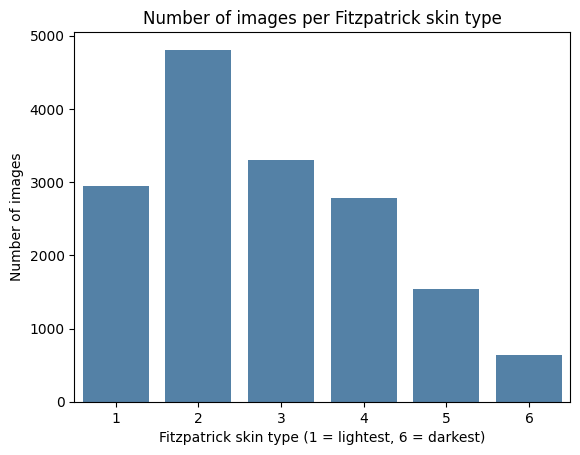

three_partition_label  benign  malignant  non-neoplastic
skin_group                                              
Dark (5-6)                9.4        9.6            81.0
Light (1-2)              14.4       15.4            70.2
Medium (3-4)             13.8       12.4            73.7


In [7]:

sns.countplot(data=df, x="fitzpatrick_scale", color="steelblue")
plt.title("Number of images per Fitzpatrick skin type")
plt.xlabel("Fitzpatrick skin type (1 = lightest, 6 = darkest)")
plt.ylabel("Number of images")
plt.show()

# Link the disease with skin types (%)
print(pd.crosstab(df["skin_group"], df["three_partition_label"], normalize="index").round(3) * 100)

As we look more deeply into the dataset, we can see how imbalanced it is: light to medium skin tones represent the vast majority of the images, while dark skin tones represent only around 14% of the dataset. This already suggests that a model trained on this raw dataset may not perform equally well on all skin tones. This raises a question: are dermatology AI models also trained on this type of dataset?
This is not specific to Fitzpatrick17k. Datasets created for dermatology AI have traditionally lacked diverse skin tones, and algorithms trained on them perform worse on darker skin (Daneshjou et al., 2021). On the Diverse Dermatology Images (DDI) dataset, state-of-the-art dermatology models performed substantially worse on dark skin (Fitzpatrick V-VI) than on light skin (I-II), and fine-tuning them on diverse images closed the gap (Daneshjou et al., 2022). This is the approach I will test in the last step of this project.
The first results of this notebook give us the following information.

Skin tone distribution. As expected, the dark skin group (types 5 and 6) is far less represented than the light and medium groups. There is a peak for type 2 (light skin), with almost 4,800 images, while type 6 only has about 635 images. This graph shows a clear imbalance and illustrates well how dark skin tones are under-represented in dermatology data.

Disease distribution. In every group, there is a large gap between non-neoplastic conditions, which represent most of the images, and benign and malignant lesions. Dark skin has the highest share of non-neoplastic images (81%).

A double imbalance. Malignant lesions represent 9.6% of dark-skin images, against 12.4% for medium skin and 15.4% for light skin. Combined with the small number of dark-skin images, this means the model will see about 6 times fewer malignant examples on dark skin than on light skin. If the model later performs worse on dark skin, this lack of examples may explain part of the gap, which I will test in the bias analysis.

These results must be interpreted with caution. They only describe this dataset: every image shows a skin condition, and the images were selected by the authors of two dermatology atlases. They cannot be used to estimate how frequent skin cancer is in people with darker skin.

Answer to the main question of this notebook. Dark skin is the least represented skin tone in the dataset. In every group, malignant lesions are a minority (from 9.6% for dark skin to 15.4% for light skin), while non-neoplastic conditions represent most of the images. This could be a problem: the model will mostly learn from non-neoplastic examples and may tend to predict "non-malignant" by default, which would lead to false negatives, meaning missed cancers. This risk is likely higher for dark skin, where the model will see very few malignant examples, so it may detect cancer less well in this group. I will measure this in the bias analysis.